In [1]:
# # Time Series Forecasting: Financial Data
# This notebook explores time series forecasting on financial data using ARIMA and ARIMAX models. 
# It includes robust data cleaning, stationarity checks, model fitting, and an optimized expanding-window cross-validation.

# ## 1. Imports and Setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA 
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Suppress convergence warnings from statsmodels for cleaner output
warnings.filterwarnings("ignore")

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# ## 2. Data Loading and Cleaning

# Aligning the index globally and handling missing data via forward-filling (LOCF) to maintain temporal continuity.

# Load dataset
file_path = r"C:\Users\H.P\Downloads\Finance-Risk Data\Financial Forecasting\financial_forecasting_dataset.csv"
df = pd.read_csv(file_path)

# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

# Set frequency (Assuming monthly start 'MS' based on standard financial periods. Adjust if daily 'D')
df = df.asfreq('MS')

# Forward-fill missing values to prevent breaks in the time series
df = df.ffill()

# Display basic information
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

display(df.head())

Data Types:
 Loan Applications        int64
Approved Loans           int64
Rejected Loans           int64
Approval Rate          float64
Average Loan Amount    float64
Total Loan Value       float64
Default Rate           float64
Revenue                float64
Interest Rate          float64
Inflation Rate         float64
Unemployment Rate      float64
GDP Growth             float64
Consumer Confidence    float64
Marketing Spend        float64
dtype: object

Missing Values:
 Loan Applications      0
Approved Loans         0
Rejected Loans         0
Approval Rate          0
Average Loan Amount    0
Total Loan Value       0
Default Rate           0
Revenue                0
Interest Rate          0
Inflation Rate         0
Unemployment Rate      0
GDP Growth             0
Consumer Confidence    0
Marketing Spend        0
dtype: int64

Duplicated Rows: 0


,Loan Applications,Approved Loans,Rejected Loans,Approval Rate,Average Loan Amount,Total Loan Value,Default Rate,Revenue,Interest Rate,Inflation Rate,Unemployment Rate,GDP Growth,Consumer Confidence,Marketing Spend
Date,,,,,,,,,,,,,,
2015-01-01,6294,4560,1734,0.724532,14987.222965,6.834174e+07,0.092119,3.417087e+06,4.099343,2.181309,4.936858,1.314746,90.779168,97131.689966
2015-02-01,6189,4159,2030,0.672156,15636.364510,6.503164e+07,0.082539,3.251582e+06,4.027874,2.725315,4.738033,2.541549,87.953223,98065.705294
2015-03-01,6437,4401,2036,0.683742,15371.800077,6.765129e+07,0.095606,3.382565e+06,4.240420,2.390069,5.507936,1.954184,93.245164,101436.233649
2015-04-01,6992,4961,2031,0.709625,14964.692834,7.423984e+07,0.081249,3.711992e+06,4.470502,3.212384,4.791903,2.495127,87.002133,99682.876144
2015-05-01,6810,4974,1836,0.730424,15585.849355,7.752401e+07,0.087880,3.876201e+06,4.173567,2.592219,5.088658,1.362229,92.436935,99635.771087


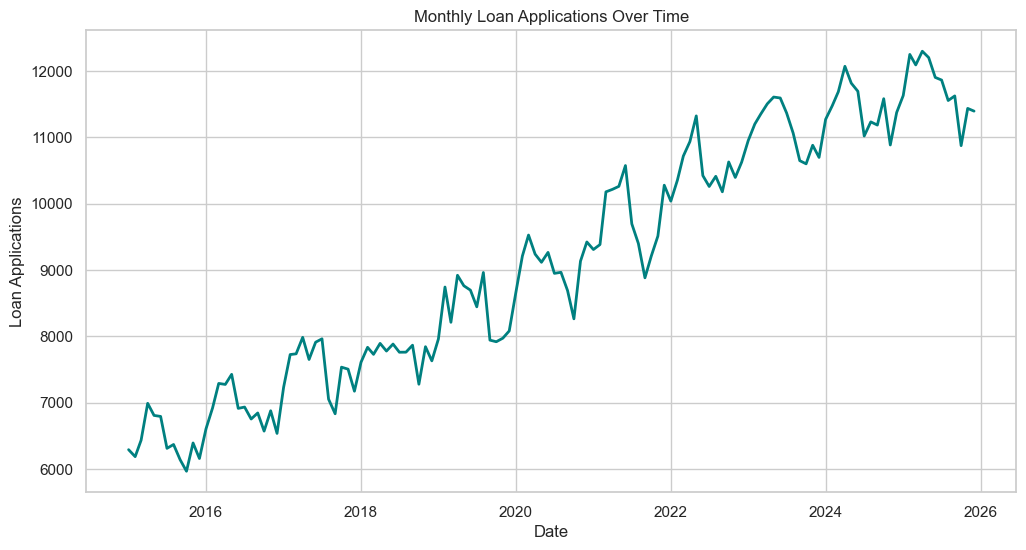

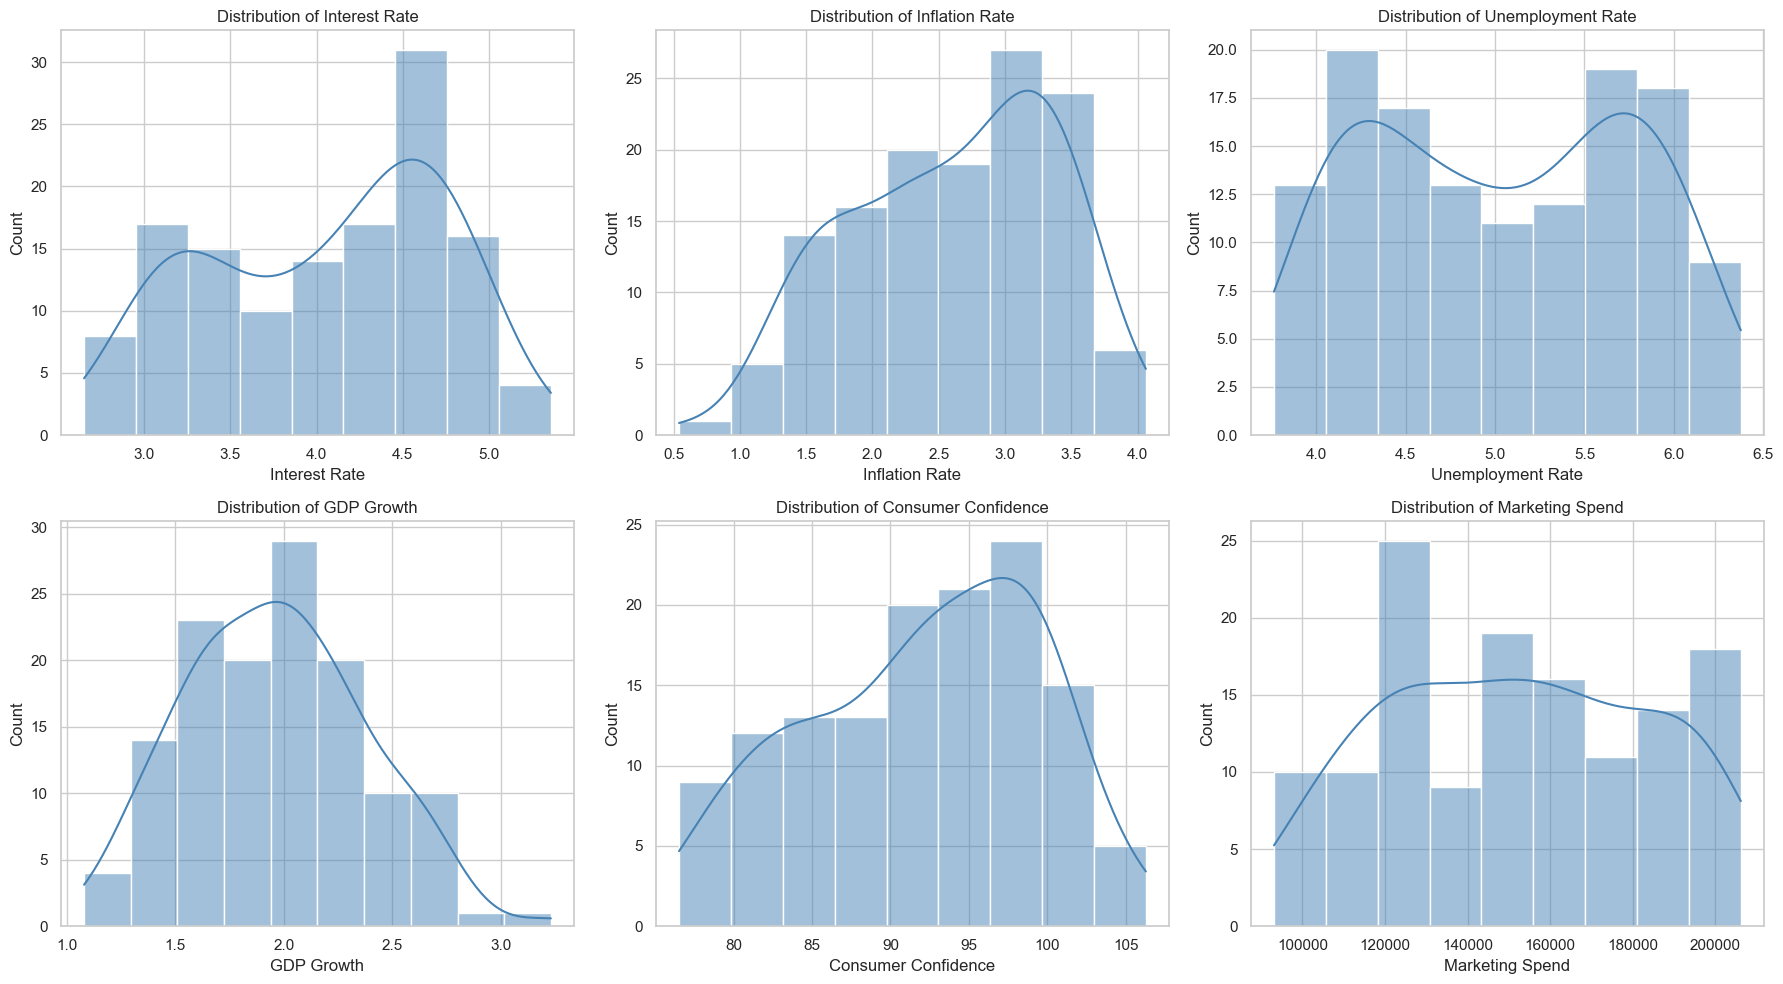

In [3]:
# ## 3. Exploratory Data Analysis (EDA)

# Visualizing the target variable and external economic factors.

# Target Variable Plot
plt.figure()
sns.lineplot(data=df, x=df.index, y='Loan Applications', color='teal', linewidth=2)
plt.title('Monthly Loan Applications Over Time')
plt.xlabel('Date')
plt.ylabel('Loan Applications')
plt.show()

# Economic Factors Distributions
external_factors = ['Interest Rate', 'Inflation Rate', 'Unemployment Rate', 
                    'GDP Growth', 'Consumer Confidence', 'Marketing Spend']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, element in enumerate(external_factors):
    sns.histplot(data=df, x=element, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'Distribution of {element}')

plt.tight_layout()
plt.show()

In [ ]:
# ## 4. Seasonal Decomposition

# Perform additive seasonal decomposition (period=8 based on previous PACF findings)
decomposition = seasonal_decompose(df['Loan Applications'], model='additive', period=8)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

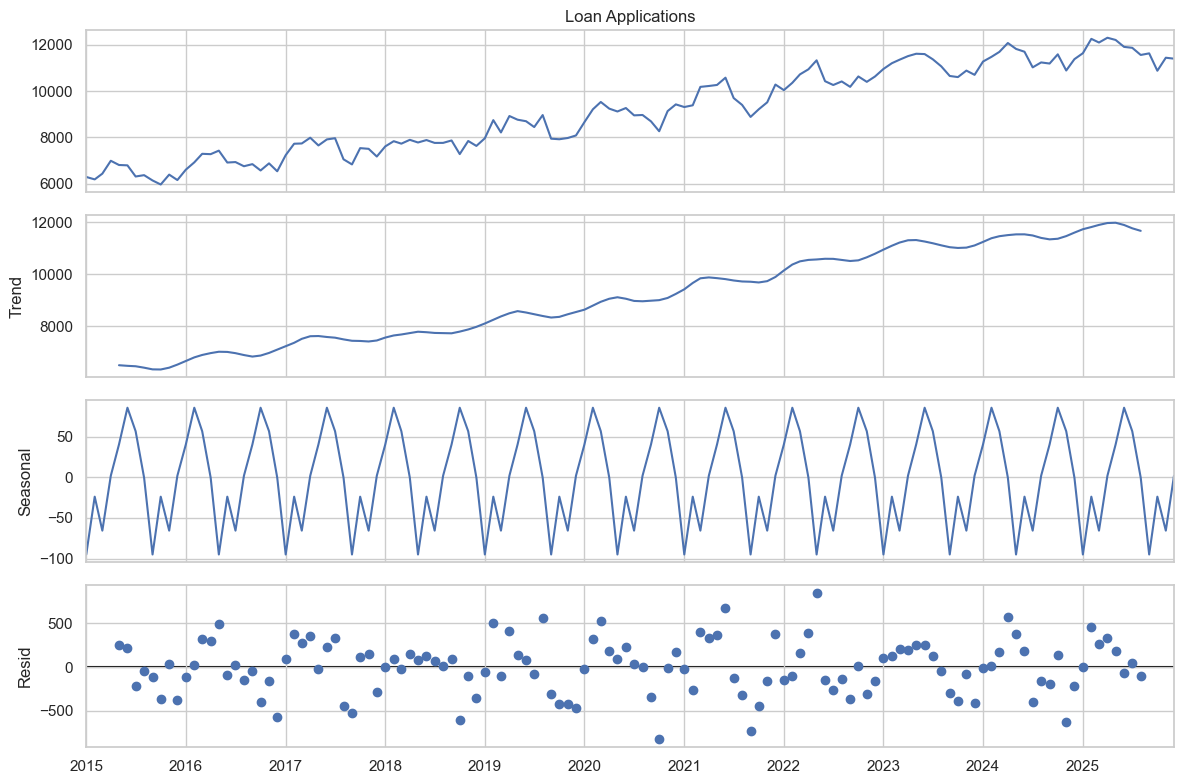

--- ADF Test: Original Loan Applications ---
ADF Statistic: -0.6733
P-value: 0.8535
Critical Values:
	1%: -3.4856
	5%: -2.8857
	10%: -2.5797


--- ADF Test: First Differenced Loan Applications ---
ADF Statistic: -8.9755
P-value: 0.0000
Critical Values:
	1%: -3.4856
	5%: -2.8857
	10%: -2.5797




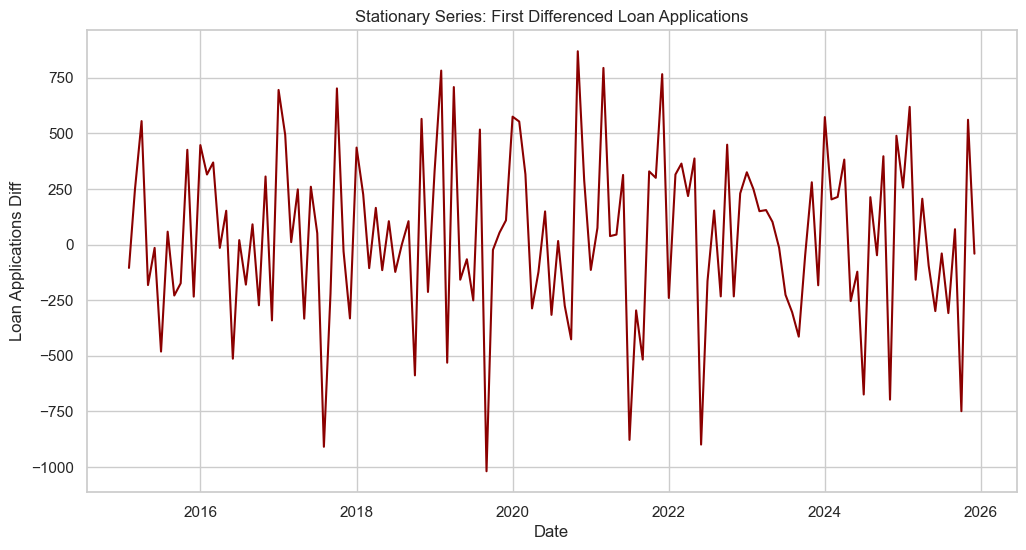

In [4]:
# ## 5. Stationarity Checks (ADF Test) and Differencing

# Checking stationarity and applying first-order differencing to stabilize the mean.
def perform_adf_test(series, title=""):
    print(f"--- ADF Test: {title} ---")
    results = adfuller(series.dropna())
    print(f"ADF Statistic: {results[0]:.4f}")
    print(f"P-value: {results[1]:.4f}")
    print("Critical Values:")
    for key, value in results[4].items():
        print(f"\t{key}: {value:.4f}")
    print("\n")

# Check original series
perform_adf_test(df['Loan Applications'], "Original Loan Applications")

# Apply First Differencing
df['Loan Applications Diff'] = df['Loan Applications'].diff()

# Check differenced series
perform_adf_test(df['Loan Applications Diff'], "First Differenced Loan Applications")

# Plot the stationary series
plt.figure()
sns.lineplot(data=df, x=df.index, y='Loan Applications Diff', color='darkred')
plt.title('Stationary Series: First Differenced Loan Applications')
plt.show()

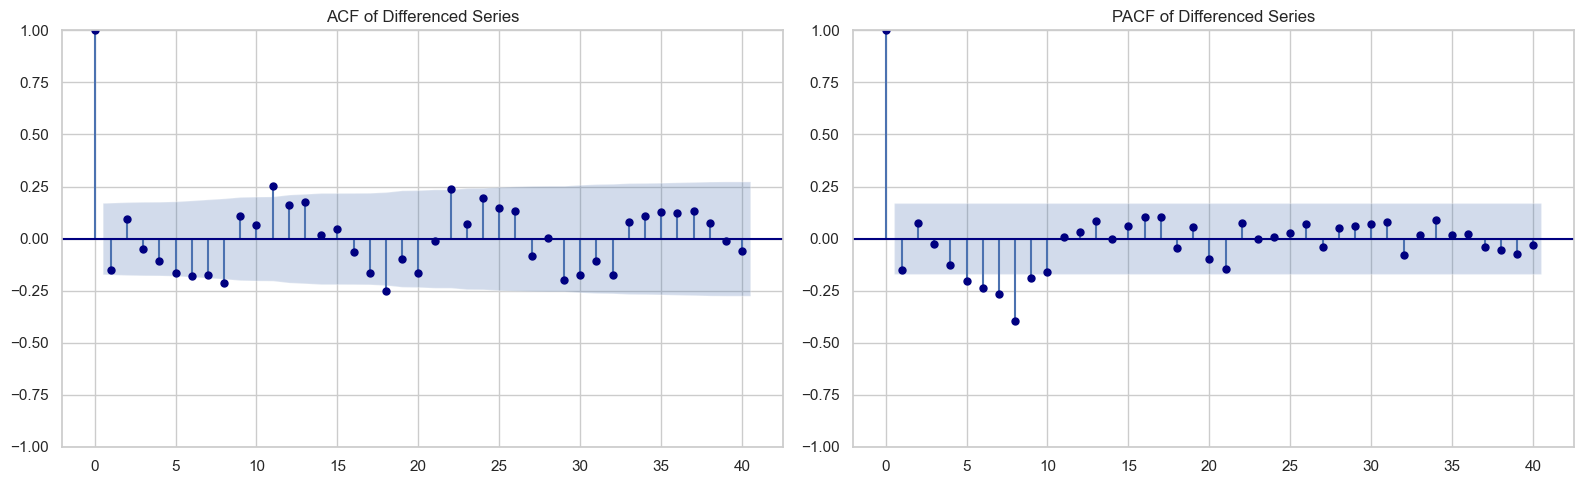

In [5]:
# ## 6. Autocorrelation (ACF) and Partial Autocorrelation (PACF)

# Drop NA values generated by differencing for ACF/PACF plots
diff_series = df['Loan Applications Diff'].dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(diff_series, lags=40, ax=ax1, color='navy')
ax1.set_title('ACF of Differenced Series')

plot_pacf(diff_series, lags=40, ax=ax2, color='navy')
ax2.set_title('PACF of Differenced Series')

plt.tight_layout()
plt.show()

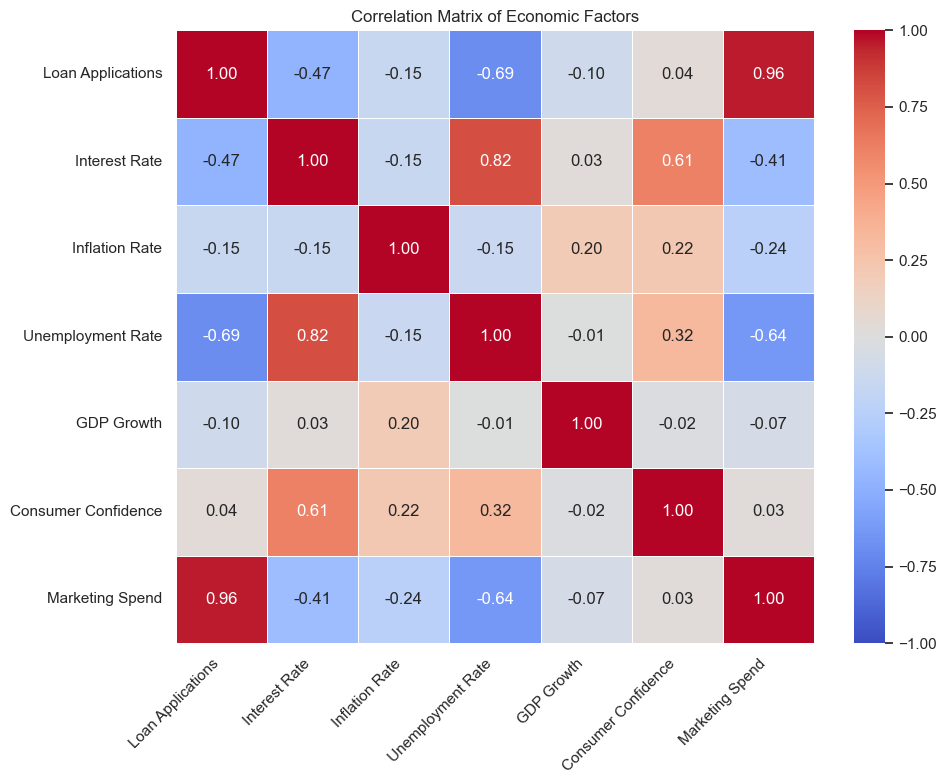

In [6]:
# ## 7. Multicollinearity Check

# Checking correlations between exogenous variables to avoid multicollinearity in ARIMAX.

corr = df[['Loan Applications'] + external_factors].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    linewidths=0.5,
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix of Economic Factors")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Note: 

In [13]:
# ## 8. Optimized Cross-Validation (ARIMA vs ARIMAX)

# Define exogenous columns
exog_cols = ['Interest Rate', 'Inflation Rate', 'GDP Growth', 'Consumer Confidence', 'Marketing Spend']
# High correlation between Unemployment Rate and Interest Rate. 
# We will remove Unemployment Rate from the ARIMAX features.

# Setup the Expanding Window Split
n_records = len(df)
train_size = int(n_records * 0.8)

train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print(f"Training on first {train_size} records. Testing on next {len(test_df)} records...")

# --- Fit Initial Models ONCE ---
# Base ARIMA
model_arima = ARIMA(train_df["Loan Applications"], order=(8, 1, 0))
fitted_arima = model_arima.fit()

# ARIMAX
model_arimax = ARIMA(train_df["Loan Applications"], exog=train_df[exog_cols], order=(8, 1, 0))
fitted_arimax = model_arimax.fit()

# Print Initial Summaries
print("\n--- Initial ARIMAX Summary ---")
print(fitted_arimax.summary().tables[1])

# --- Run Optimized Cross-Validation ---
actuals = []
predictions_arima = []
predictions_arimax = []

for i in range(len(test_df)):
    # 1. Forecast 1-step ahead
    # ARIMA forecast
    fc_arima = fitted_arima.forecast(steps=1)
    predictions_arima.append(fc_arima.values[0])
    
    # ARIMAX forecast (requires current step's exogenous data)
    current_exog = test_df[exog_cols].iloc[[i]]
    fc_arimax = fitted_arimax.forecast(steps=1, exog=current_exog)
    predictions_arimax.append(fc_arimax.values[0])
    
    # Store Actual Target
    actual_target = test_df["Loan Applications"].iloc[[i]]
    actuals.append(actual_target.values[0])
    
    # 2. Update the models with the new observation (prevents full refit)
    fitted_arima = fitted_arima.extend(actual_target)
    fitted_arimax = fitted_arimax.extend(actual_target, exog=current_exog)


Training on first 105 records. Testing on next 27 records...

--- Initial ARIMAX Summary ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Interest Rate        -168.5209    132.257     -1.274      0.203    -427.740      90.698
Inflation Rate        197.8213     74.220      2.665      0.008      52.354     343.289
GDP Growth             14.4393     70.082      0.206      0.837    -122.918     151.797
Consumer Confidence    31.4514      8.661      3.631      0.000      14.476      48.426
Marketing Spend         0.0044      0.005      0.974      0.330      -0.004       0.013
ar.L1                  -0.0287      0.109     -0.264      0.792      -0.242       0.185
ar.L2                   0.0715      0.111      0.643      0.520      -0.146       0.289
ar.L3                   0.0455      0.116      0.390      0.696      -0.183       0.274
ar.L4                  -0.1

--- Cross-Validation Results ---
ARIMA  - RMSE: 369.44 | MAE: 297.78
ARIMAX - RMSE: 365.52 | MAE: 304.82


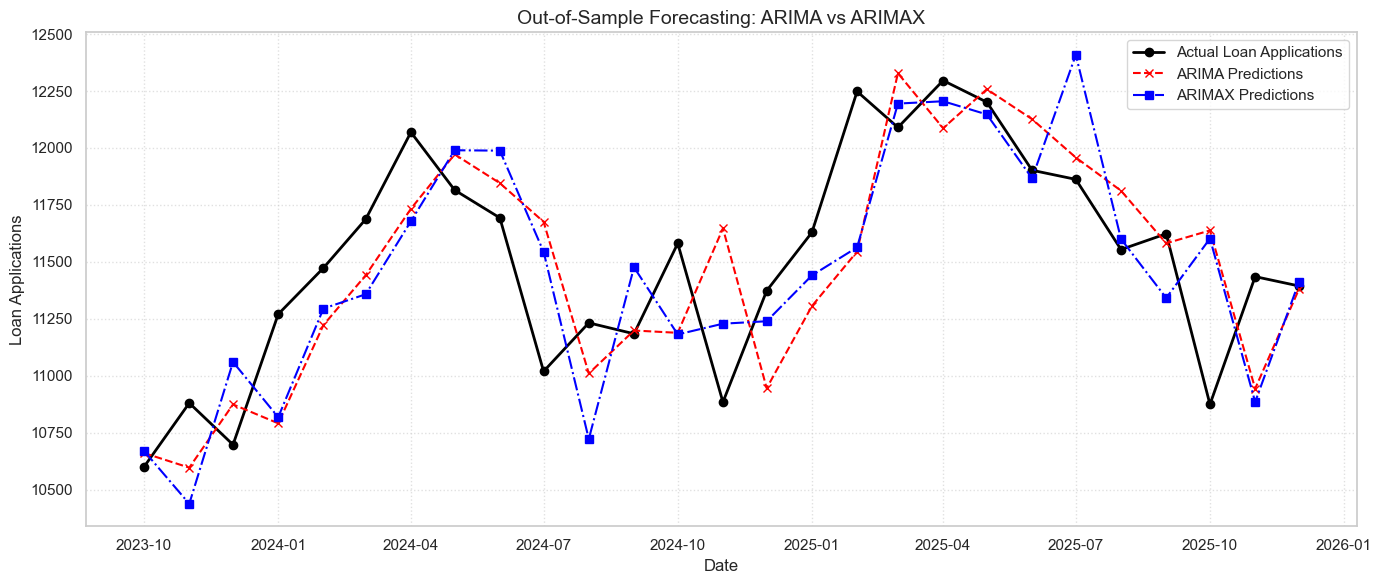

In [14]:
# ## 9. Model Evaluation and Plotting

# Calculate Metrics
rmse_arima = np.sqrt(mean_squared_error(actuals, predictions_arima))
mae_arima = mean_absolute_error(actuals, predictions_arima)

rmse_arimax = np.sqrt(mean_squared_error(actuals, predictions_arimax))
mae_arimax = mean_absolute_error(actuals, predictions_arimax)

print("--- Cross-Validation Results ---")
print(f"ARIMA  - RMSE: {rmse_arima:.2f} | MAE: {mae_arima:.2f}")
print(f"ARIMAX - RMSE: {rmse_arimax:.2f} | MAE: {mae_arimax:.2f}")

# Plot Actuals vs Predictions
plt.figure(figsize=(14, 6))
plt.plot(test_df.index, actuals, label='Actual Loan Applications', color='black', marker='o', linewidth=2)
plt.plot(test_df.index, predictions_arima, label='ARIMA Predictions', linestyle='--', color='red', marker='x')
plt.plot(test_df.index, predictions_arimax, label='ARIMAX Predictions', linestyle='-.', color='blue', marker='s')

plt.title("Out-of-Sample Forecasting: ARIMA vs ARIMAX", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Loan Applications")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

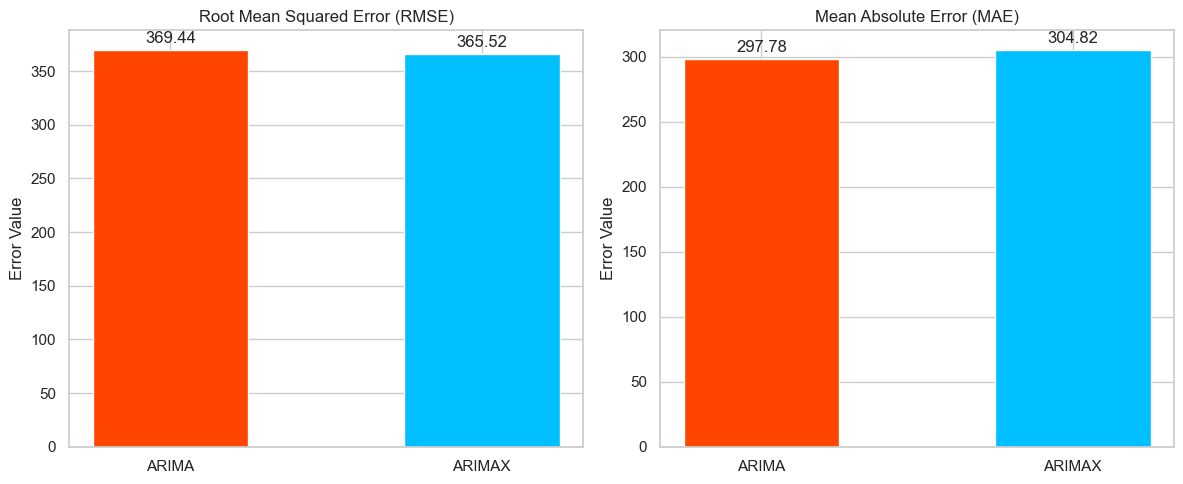

In [15]:
# ## 10. Visual Metric Comparison
models = ['ARIMA', 'ARIMAX']
rmse_values = [rmse_arima, rmse_arimax]
mae_values = [mae_arima, mae_arimax]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['orangered', 'deepskyblue']

# RMSE Bar Plot
bars1 = ax1.bar(models, rmse_values, color=colors, width=0.5)
ax1.set_title('Root Mean Squared Error (RMSE)')
ax1.set_ylabel('Error Value')
ax1.bar_label(bars1, padding=3, fmt='%.2f') 

# MAE Bar Plot
bars2 = ax2.bar(models, mae_values, color=colors, width=0.5)
ax2.set_title('Mean Absolute Error (MAE)')
ax2.set_ylabel('Error Value')
ax2.bar_label(bars2, padding=3, fmt='%.2f')

plt.tight_layout()
plt.show()